In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import os
import datetime
from datetime import timedelta
from matplotlib import ticker
from matplotlib.axes import Axes
import matplotlib
from cartopy.mpl.geoaxes import GeoAxes
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy import stats
import scipy
import matplotlib.dates as mdates
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker
import shapefile as shp
import matplotlib.patches as patches
#from tqdm import tqdm

#import warnings
#warnings.filterwarnings("ignore")

#GeoAxes._pcolormesh_patched = Axes.pcolormesh

## Open preprocessed data

In [2]:
shapefile_dir = '/gpfsm/dnb33/civanovi/data/cartopy_shape_files/'

coastlines = shp.Reader(shapefile_dir + 'ne_10m_coastline/ne_10m_coastline.shp')
states = shp.Reader(shapefile_dir + 'ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')

In [3]:
# Open real land mask
frac_land = xr.open_dataset('/discover/nobackup/projects/gmao/merra2/data/products/MERRA2_all/MERRA2.const_2d_ctm_Nx.00000000.nc4').FRLAND

land_mask = xr.where(frac_land.mean(dim = 'time') > 0.5, 1, np.nan)
land_mask.load();

mask_array = land_mask.to_numpy()

In [4]:
# Save out text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'

peak_month_T95 = np.loadtxt(save_dir + 'month_highestT95_1980-1989_baseperiod.txt', delimiter=',')
peak_month_WBGT95 = np.loadtxt(save_dir + 'month_highestWBGT95_1980-1989_baseperiod.txt', delimiter=',')

mid_month_T95 = np.loadtxt(save_dir + 'middlemonth_3month_highestT95_1980-1989_baseperiod.txt', delimiter=',')
mid_month_WBGT95 = np.loadtxt(save_dir + 'middlemonth_3month_highestWBGT95_1980-1989_baseperiod.txt', delimiter=',')

In [5]:
peak_month_T95_da = xr.DataArray(peak_month_T95, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

peak_month_WBGT95_da = xr.DataArray(peak_month_WBGT95, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

In [6]:
data_dir = '/home/civanovi/JupyterLinks/nobackup/data/MERRA2/processed_data/'
monthly_T95_count = xr.open_dataarray(data_dir + 'global_T95_days_monthly_count_1980-1989_baseperiod.nc')
monthly_WBGT95_count = xr.open_dataarray(data_dir + 'global_WBGT95_days_monthly_count_1980-1989_baseperiod.nc')

In [7]:
early_period = ['01-01-1980', '12-31-1989']
early_period_title = 'Early Period: 1980-1989'

late_period = ['01-01-2015', '12-31-2024']
late_period_title = 'Late Period: 2015-2024'

monthly_T95_count_early = monthly_T95_count.sel(time = slice(early_period[0],early_period[1]))
monthly_WBGT95_count_early = monthly_WBGT95_count.sel(time = slice(early_period[0],early_period[1]))

In [8]:
monthly_T95_early_counts = monthly_T95_count_early.groupby('time.month').sum()
monthly_WBGT95_early_counts = monthly_WBGT95_count_early.groupby('time.month').sum()

# Calculate fraction of extremes that happen in 1) peak month, 2) extreme heat season, 3) extreme heat season + shoulder seasons

In [85]:
# Iterate through each grid cell and determine what fraction of events happen in 2 months before and after heat season
peak_months_data = [peak_month_T95,peak_month_WBGT95]
mid_months_data = [mid_month_T95,mid_month_WBGT95]
monthly_extremes_counts_data = [monthly_T95_early_counts,monthly_WBGT95_early_counts]

peak_month_frac_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))
heat_season_frac_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))
heat_and_shoulders_frac_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))

peak_month_frac_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))
heat_season_frac_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))
heat_and_shoulders_frac_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))

# Do this for full historical period, but then do for early and late historical period
for k, peak_months in enumerate(peak_months_data):

    mid_months = mid_months_data[k]
    monthly_extremes_counts = monthly_extremes_counts_data[k]
    
    for i in tqdm(range(np.shape(peak_months)[0])):
        
        for j in range(np.shape(peak_months)[1]):

            gc_extremes = monthly_extremes_counts.isel(lat = i, lon = j)
            peak_month = peak_months[i,j]

            mid_month = mid_months[i,j]

            if (mid_month - mid_month) != 0:

                if k == 0:
                    peak_month_frac_T[i,j] = gc_extremes.sel(month = peak_month).sum()/gc_extremes.sum()
                    heat_season_frac_T[i,j] = np.nan
                    heat_and_shoulders_frac_T[i,j] = np.nan
                else:
                    peak_month_frac_WBGT[i,j] = gc_extremes.sel(month = peak_month).sum()/gc_extremes.sum()
                    heat_season_frac_WBGT[i,j] = np.nan
                    heat_and_shoulders_frac_WBGT[i,j] = np.nan

            else:
    
                # Find heat season months
                if mid_month == 1:
                    heat_season = [12,1,2]
                elif mid_month == 12:
                    heat_season = [11,12,1]
                else:
                    heat_season = [mid_month-1,mid_month,mid_month+1]

                # Outside months
                before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
                after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

                # Adjust if this gives negative numbers
                before_season = [x if x > 0  else (x+12) for x in before_season_temp]

                after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

                # Put all these together into greater heat and shoulder season
                heat_and_shoulder_season = before_season + heat_season + after_season

                # Find fraction of events happening in each period
                peak_month_extremes = gc_extremes.sel(month = peak_month).sum()/gc_extremes.sum()
                heat_season_extremes = gc_extremes.sel(month = heat_season).sum()/gc_extremes.sum()
                heat_and_shoulder_season_extremes = gc_extremes.sel(month = heat_and_shoulder_season).sum()/gc_extremes.sum()
                
                if k == 0:
                    peak_month_frac_T[i,j] = peak_month_extremes
                    heat_season_frac_T[i,j] = heat_season_extremes
                    heat_and_shoulders_frac_T[i,j] = heat_and_shoulder_season_extremes
                else:
                    peak_month_frac_WBGT[i,j] = peak_month_extremes
                    heat_season_frac_WBGT[i,j] = heat_season_extremes
                    heat_and_shoulders_frac_WBGT[i,j] = heat_and_shoulder_season_extremes

100%|██████████| 361/361 [10:09<00:00,  1.69s/it]


In [86]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s/'

peak_month_frac_T_da = xr.DataArray(peak_month_frac_T, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

heat_season_frac_T_da = xr.DataArray(heat_season_frac_T, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

heat_and_shoulders_frac_T_da = xr.DataArray(heat_and_shoulders_frac_T, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

peak_month_frac_WBGT_da = xr.DataArray(peak_month_frac_WBGT, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

heat_season_frac_WBGT_da = xr.DataArray(heat_season_frac_WBGT, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

heat_and_shoulders_frac_WBGT_da = xr.DataArray(heat_and_shoulders_frac_WBGT, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

In [87]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s/'

peak_month_frac_T_da.to_netcdf(save_dir + 'fraction_T95_events_during_peak_T95_month.nc')
heat_season_frac_T_da.to_netcdf(save_dir + 'fraction_T95_events_during_T95_extremeheatseason.nc')
heat_and_shoulders_frac_T_da.to_netcdf(save_dir + 'fraction_T95_events_during_T95_extremeheat_and_shoulderseason.nc')

peak_month_frac_WBGT_da.to_netcdf(save_dir + 'fraction_WBGT95_events_during_peak_WBGT95_month.nc')
heat_season_frac_WBGT_da.to_netcdf(save_dir + 'fraction_WBGT95_events_during_WBGT95_extremeheatseason.nc')
heat_and_shoulders_frac_WBGT_da.to_netcdf(save_dir + 'fraction_WBGT95_events_during_WBGT95_extremeheat_and_shoulderseason.nc')

### Calculate number of events that happen during shoulder seasons (individually)

Want to determine how many grid cells have 0 extreme events in one shoulder season in baseline period

In [15]:
# Iterate through each grid cell and determine what fraction of events happen in 2 months before and after heat season
peak_months_data = [peak_month_T95,peak_month_WBGT95]
mid_months_data = [mid_month_T95,mid_month_WBGT95]
monthly_extremes_counts_data = [monthly_T95_early_counts,monthly_WBGT95_early_counts]

pre_count_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))
post_count_T = np.zeros((np.shape(monthly_T95_early_counts)[1], np.shape(monthly_T95_early_counts)[2]))

pre_count_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))
post_count_WBGT = np.zeros((np.shape(monthly_WBGT95_early_counts)[1], np.shape(monthly_WBGT95_early_counts)[2]))

# Do this for full historical period, but then do for early and late historical period
for k, peak_months in enumerate(peak_months_data):

    mid_months = mid_months_data[k]
    monthly_extremes_counts = monthly_extremes_counts_data[k]
    
    for i in tqdm(range(np.shape(peak_months)[0])):
        
        for j in range(np.shape(peak_months)[1]):

            gc_extremes = monthly_extremes_counts.isel(lat = i, lon = j)
            peak_month = peak_months[i,j]

            mid_month = mid_months[i,j]

            if (mid_month - mid_month) != 0:

                if k == 0:
                    pre_count_T[i,j] = np.nan
                    post_count_T[i,j] = np.nan
                else:
                    pre_count_WBGT[i,j] = np.nan
                    post_count_WBGT[i,j] = np.nan

            else:
    
                # Find heat season months
                if mid_month == 1:
                    heat_season = [12,1,2]
                elif mid_month == 12:
                    heat_season = [11,12,1]
                else:
                    heat_season = [mid_month-1,mid_month,mid_month+1]

                # Outside months
                before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
                after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

                # Adjust if this gives negative numbers
                before_season = [x if x > 0  else (x+12) for x in before_season_temp]

                after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

                # Find fraction of events happening in each period
                pre_count_extremes = gc_extremes.sel(month = before_season).sum()
                post_count_extremes = gc_extremes.sel(month = after_season).sum()
                
                if k == 0:
                    pre_count_T[i,j] = pre_count_extremes
                    post_count_T[i,j] = post_count_extremes
                else:
                    pre_count_WBGT[i,j] = pre_count_extremes
                    post_count_WBGT[i,j] = post_count_extremes

100%|██████████| 361/361 [04:20<00:00,  1.38it/s]


In [16]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s/'

pre_count_T_da = xr.DataArray(pre_count_T, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

post_count_T_da = xr.DataArray(post_count_T, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

pre_count_WBGT_da = xr.DataArray(pre_count_WBGT, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

post_count_WBGT_da = xr.DataArray(post_count_WBGT, 
                                coords={'lat': frac_land.lat,'lon': frac_land.lon}, 
                                dims=["lat", "lon"])

In [17]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s/'

pre_count_T_da.to_netcdf(save_dir + 'counts_T95_events_during_preseason_T95.nc')
post_count_T_da.to_netcdf(save_dir + 'counts_T95_events_during_postseason_T95.nc')

pre_count_WBGT_da.to_netcdf(save_dir + 'counts_WBGT95_events_during_preseason_WBGT95.nc')
post_count_WBGT_da.to_netcdf(save_dir + 'counts_WBGT95_events_during_postseason_WBGT95.nc')

In [30]:
# Calculate fractions
preT_1D = np.ravel(pre_count_T*mask_array)
postT_1D = np.ravel(post_count_T*mask_array)

shoulderT_0 = np.where((preT_1D == 0) | (postT_1D == 0), 1, 0)
shoulderT_frac = np.nansum(shoulderT_0)/np.nansum(mask_array)

print(shoulderT_frac)

preWBGT_1D = np.ravel(pre_count_WBGT*mask_array)
postWBGT_1D = np.ravel(post_count_WBGT*mask_array)

shoulderWBGT_0 = np.where((preWBGT_1D == 0) | (postWBGT_1D == 0), 1, 0)
shoulderWBGT_frac = np.nansum(shoulderWBGT_0)/np.nansum(mask_array)

print(shoulderWBGT_frac)

0.49492676805919134
0.4445838651753456


# Plot combined figures

In [9]:
# Open preprocessed data
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/baseperiod_1980s/'

peak_month_frac_T_da = xr.open_dataarray(save_dir + 'fraction_T95_events_during_peak_T95_month.nc')
heat_season_frac_T_da = xr.open_dataarray(save_dir + 'fraction_T95_events_during_T95_extremeheatseason.nc')
heat_and_shoulders_frac_T_da = xr.open_dataarray(save_dir + 'fraction_T95_events_during_T95_extremeheat_and_shoulderseason.nc')

peak_month_frac_WBGT_da = xr.open_dataarray(save_dir + 'fraction_WBGT95_events_during_peak_WBGT95_month.nc')
heat_season_frac_WBGT_da = xr.open_dataarray(save_dir + 'fraction_WBGT95_events_during_WBGT95_extremeheatseason.nc')
heat_and_shoulders_frac_WBGT_da = xr.open_dataarray(save_dir + 'fraction_WBGT95_events_during_WBGT95_extremeheat_and_shoulderseason.nc')

In [10]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

seasons_real_T = np.loadtxt(save_dir + 'local_T_heat_season_2monthsbefore_T95_count.txt',  delimiter=',')
seasons_real_WBGT = np.loadtxt(save_dir + 'local_WBGT_heat_season_2monthsbefore_WBGT95_count.txt',  delimiter=',')

In [11]:
# Open real land mask
frac_land = xr.open_dataset('/discover/nobackup/projects/gmao/merra2/data/products/MERRA2_all/MERRA2.const_2d_ctm_Nx.00000000.nc4').FRLAND

land_mask = xr.where(frac_land.mean(dim = 'time') > 0.5, 1, np.nan)
land_mask.load();
mask_array = land_mask.to_numpy()

ocean_mask = xr.where(frac_land.mean(dim = 'time') < 0.5, 1, np.nan)
ocean_mask.load();
ocean_array = ocean_mask.to_numpy()

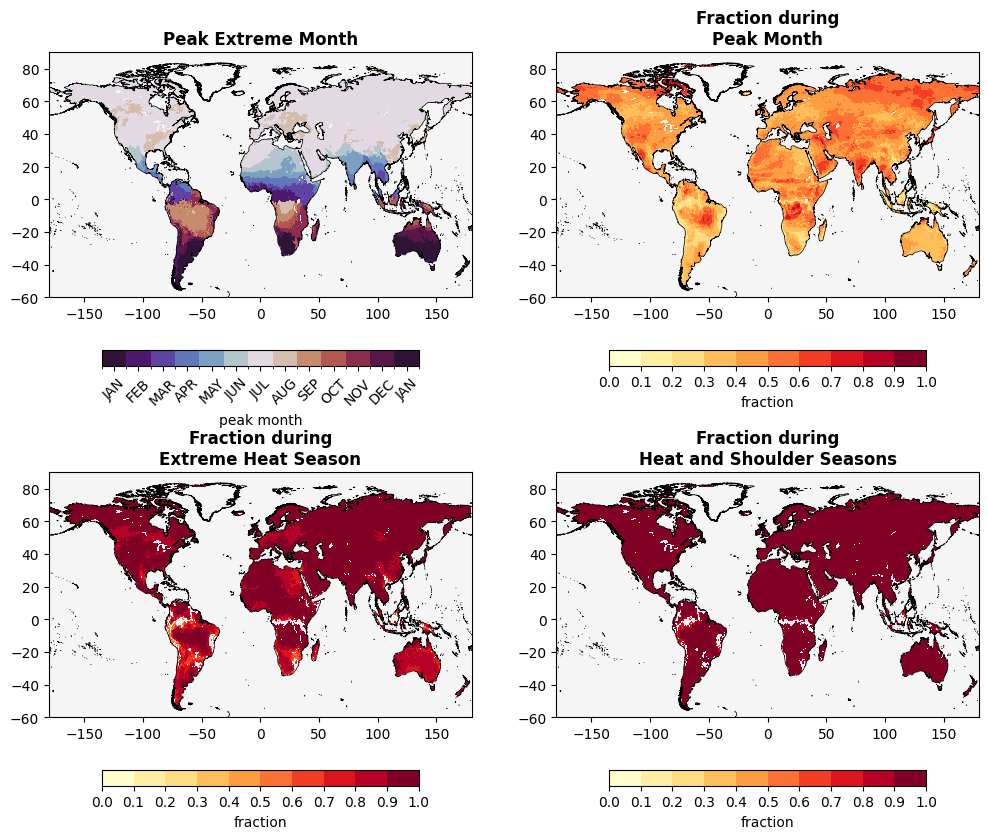

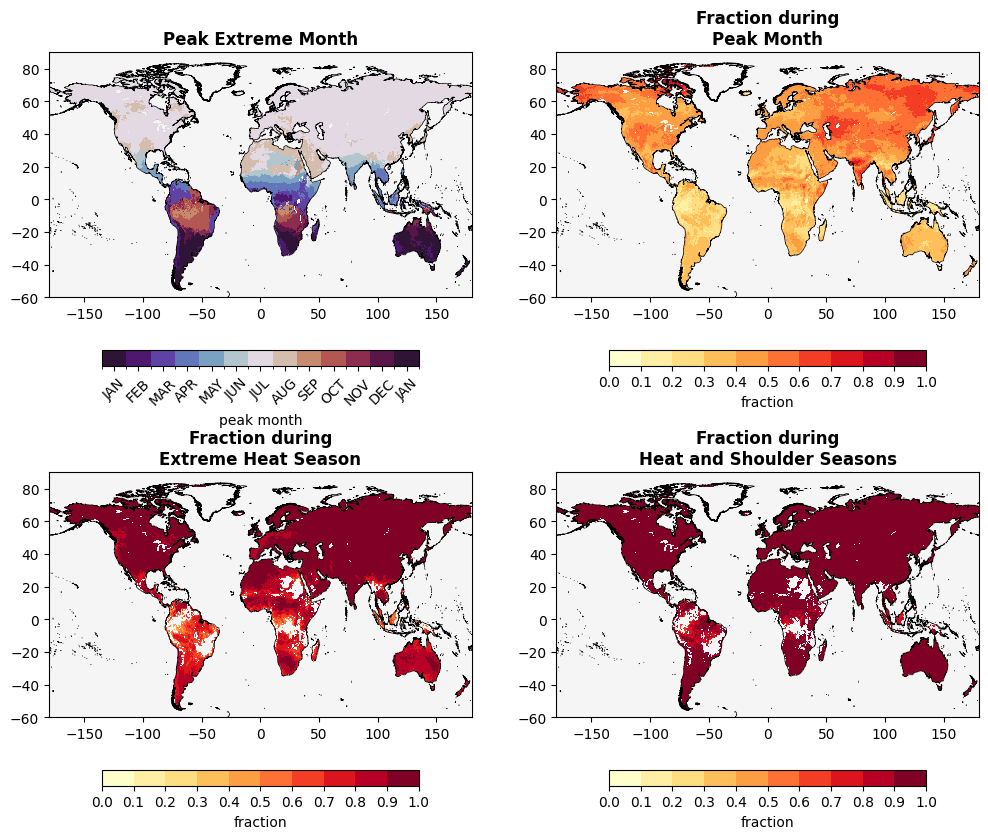

In [17]:
T_data = [peak_month_T95_da,peak_month_frac_T_da,heat_season_frac_T_da,heat_and_shoulders_frac_T_da]
WBGT_data = [peak_month_WBGT95_da,peak_month_frac_WBGT_da,heat_season_frac_WBGT_da,heat_and_shoulders_frac_WBGT_da]

datasets = [T_data, WBGT_data]
titles = ['Peak Extreme Month','Fraction during\nPeak Month','Fraction during\nExtreme Heat Season','Fraction during\nHeat and Shoulder Seasons']

for data in datasets:

    fig, axs = plt.subplots(2,2, figsize = (12,10))

    for i, ax in enumerate(fig.axes):

        plot_data = data[i]*mask_array

        if i == 0:
            cmap = matplotlib.cm.twilight_shifted
            bounds = np.arange(0.5, 14.5, 1)
            norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
            cmap.set_bad('whitesmoke',1.)
            label = 'peak month'
            ticks = np.arange(1,14,1)
            tick_labels = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC','JAN']
            rotation = 45
        else:
            cmap = matplotlib.cm.YlOrRd
            bounds = np.arange(0, 1.1, 0.1)
            norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
            cmap.set_bad('whitesmoke',1.)
            label = 'fraction'
            ticks = [np.round(x,1) for x in bounds]
            tick_labels = ticks
            rotation = 0

        mesh = ax.pcolormesh(plot_data.lon, plot_data.lat, plot_data, norm = norm, cmap = cmap)
        cbar = plt.colorbar(mesh, ax = ax, shrink = 0.75, orientation = 'horizontal', ticks = ticks, label = label)
        cbar.ax.set_xticklabels(tick_labels);
        cbar.ax.tick_params(rotation = rotation)
        
        ax.set_title(titles[i],fontweight = 'bold')
        ax.set_ylim([-60,90])
        ax.set_xlim([-180,180])

        # Plot coastlines
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            ax.plot(x,y, color = 'k', linewidth = 0.5)

/home/civanovi/.conda/envs/PyWBGT/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:306: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)
/home/civanovi/.conda/envs/PyWBGT/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:306: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)
/home/civanovi/.conda/envs/PyWBGT/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:306: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)
/home/civanovi/.conda/envs/PyWBGT/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:306: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args

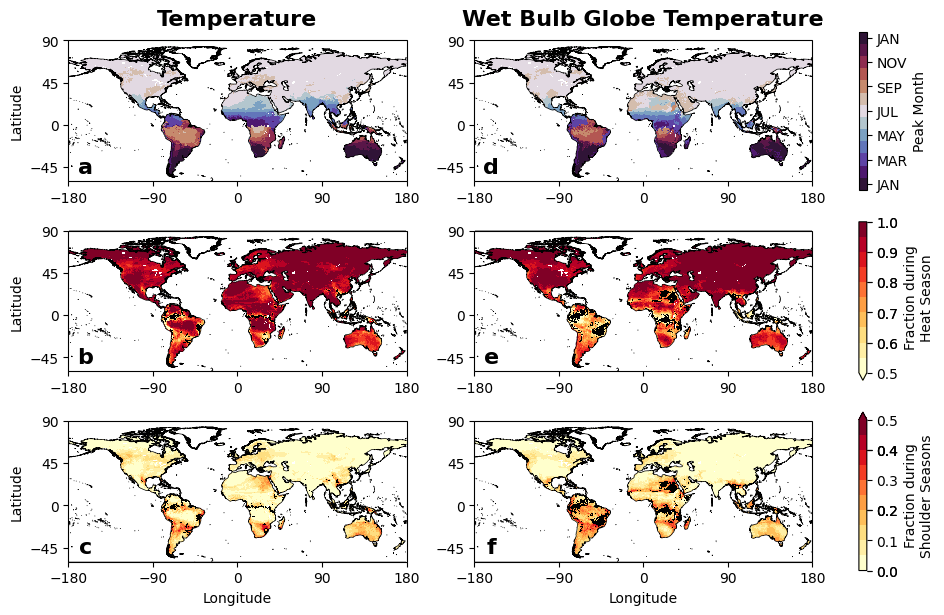

In [12]:
# Plot one figure with two columns

T_data = [peak_month_T95_da,heat_season_frac_T_da,heat_and_shoulders_frac_T_da - heat_season_frac_T_da]
WBGT_data = [peak_month_WBGT95_da,heat_season_frac_WBGT_da,heat_and_shoulders_frac_WBGT_da - heat_season_frac_WBGT_da]
panel_labels = [['a','b','c'],['d','e','f']]

rows = 3
columns = 2

fig, axs = plt.subplots(rows,columns, figsize = (12,7), facecolor = 'w', edgecolor = 'k', subplot_kw = {'projection': ccrs.PlateCarree()})

for i in range(columns):

    if i == 0:
        data = T_data
        extreme = 'T'
        column_name = 'Temperature'
        seasons_real = seasons_real_T
        
    else:
        data = WBGT_data
        extreme = 'WBGT'
        column_name = 'Wet Bulb Globe Temperature'
        seasons_real = seasons_real_WBGT

    for j in range(rows):

        plot_data = data[j]*mask_array
    
        if j == 0:
            cmap = matplotlib.cm.twilight_shifted
            bounds = np.arange(0.5, 14.5, 1)
            norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
            cmap.set_bad('k',1.)
            label = 'Peak Month'
            ticks = np.arange(1,14,2)
            #tick_labels = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC','JAN']
            tick_labels = ['JAN','MAR','MAY','JUL','SEP','NOV','JAN']
            rotation = 45
            axs[j,i].text(0.5, 1.15, column_name, transform=axs[j,i].transAxes, 
                          fontsize=16, fontweight = 'bold', verticalalignment='center', horizontalalignment='center')
            extend = 'neither'
        else:
            if j == 1:
                bounds = np.arange(0.5, 1.05, 0.05)
                label = 'Fraction during\nHeat Season'
                extend = 'min'
            else:
                bounds = np.arange(0, 0.55, 0.05)
                label = 'Fraction during\nShoulder Seasons'
                extend = 'max'
                
            cmap = matplotlib.cm.YlOrRd
            norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)
            cmap.set_bad('k',1.)
            ticks = [np.round(x,1) for x in bounds]
            tick_labels = ticks
            rotation = 0
    
        mesh = axs[j,i].pcolormesh(plot_data.lon, plot_data.lat, plot_data, norm = norm, cmap = cmap)

        # Plot ocean white on top of everything
        ocean_mesh = axs[j,i].pcolormesh(plot_data.lon, plot_data.lat, ocean_array, cmap = 'binary')

        axs[j,i].set_ylim([-60,90])
        axs[j,i].set_yticks([-45,0,45,90])
        axs[j,i].set_xlim([-180,180])
        axs[j,i].set_xticks([-180,-90,0,90,180])

        # Plot coastlines
        for shape in coastlines.shapeRecords():
            x = [m[0] for m in shape.shape.points[:]]
            y = [m[1] for m in shape.shape.points[:]]
            axs[j,i].plot(x,y, color = 'k', linewidth = 0.5)

        # Add colorbar just to the right column
        if i == 1:
            cbar = plt.colorbar(mesh, ax = axs[j,:], orientation = 'vertical', ticks = ticks, label = label, extend = extend)
            cbar.ax.set_yticks(ticks);
            cbar.ax.set_yticklabels(tick_labels);
            #cbar.ax.tick_params(rotation = rotation)
            cbar.ax.minorticks_off()

        if i == 0:
            axs[j,i].set_ylabel('Latitude')

        if j == 2:
            axs[j,i].set_xlabel('Longitude')

        axs[j,i].text(0.05, 0.1, panel_labels[i][j], transform=axs[j,i].transAxes,
                     fontsize=16, fontweight = 'bold', verticalalignment='center', horizontalalignment='center')

# Calculations for main text 

In [34]:
# How much of world experiences over 80% of extremes during heat season?
T_val = xr.where(heat_season_frac_T_da > 0.80, 1, 0)*mask_array
WBGT_val = xr.where(heat_season_frac_WBGT_da > 0.80, 1, 0)*mask_array

In [35]:
100*np.nansum(T_val)/np.nansum(mask_array)

89.39272656469723

In [36]:
100*np.nansum(WBGT_val)/np.nansum(mask_array)

78.63834022023669

In [75]:
lat_band = [-30,-15]

heat_and_shoulders_frac_T_da = heat_and_shoulders_frac_T_da*mask_array
heat_season_frac_T_da = heat_season_frac_T_da*mask_array

heat_and_shoulders_frac_WBGT_da = heat_and_shoulders_frac_WBGT_da*mask_array
heat_season_frac_WBGT_da = heat_season_frac_WBGT_da*mask_array

mean_T_shoulder = np.nanmean(heat_and_shoulders_frac_T_da.sel(lat = slice(lat_band[0],lat_band[1])) - heat_season_frac_T_da.sel(lat = slice(lat_band[0],lat_band[1])))
mean_WBGT_shoulder = np.nanmean(heat_and_shoulders_frac_WBGT_da.sel(lat = slice(lat_band[0],lat_band[1])) - heat_season_frac_WBGT_da.sel(lat = slice(lat_band[0],lat_band[1])))

print(mean_T_shoulder)
print(mean_WBGT_shoulder)

0.17307004350228503
0.18511891018240592


In [76]:
# Elsewhere in the world

mean_T_shoulder_elsewhere = np.nanmean(heat_and_shoulders_frac_T_da.where((heat_and_shoulders_frac_T_da.lat < lat_band[0]) | (heat_and_shoulders_frac_T_da.lat > lat_band[1]), drop=True)
                                   - heat_season_frac_T_da.where((heat_season_frac_T_da.lat < lat_band[0]) | (heat_season_frac_T_da.lat > lat_band[1]), drop=True))
mean_WBGT_shoulder_elsewhere = np.nanmean(heat_and_shoulders_frac_WBGT_da.where((heat_and_shoulders_frac_WBGT_da.lat < lat_band[0]) | (heat_and_shoulders_frac_WBGT_da.lat > lat_band[1]), drop=True)
                                   - heat_season_frac_WBGT_da.where((heat_season_frac_WBGT_da.lat < lat_band[0]) | (heat_season_frac_WBGT_da.lat > lat_band[1]), drop=True))

print(mean_T_shoulder_elsewhere)
print(mean_WBGT_shoulder_elsewhere)

0.055400878933383274
0.06332916982678063


In [25]:
# Do all grid cells have at least 50% of extremes in heat season?
heat_season_frac_array = np.array(heat_season_frac_WBGT_da).flatten()
len(heat_season_frac_array[heat_season_frac_array > 0.5])/len(heat_season_frac_array)

0.9451177285318559

In [24]:
heat_season_frac_array = np.array(heat_season_frac_T_da).flatten()
len(heat_season_frac_array[heat_season_frac_array > 0.5])/len(heat_season_frac_array)

0.9403277931671283